# Lensed cubes: kinematics through a gravitational lens

SuperMAGE interfaces with
[caustics](https://github.com/Ciela-Institute/caustics) to model strongly
lensed gas disks — e.g. high-redshift dusty star-forming galaxies whose CO
or [CII] emission is stretched into arcs and rings. Two simulators are
available:

- **`AnalyticLens`** *(recommended)* — raytraces the image-plane grid to
  the source plane **once per call** and evaluates the analytic
  intensity/velocity fields *directly at the raytraced positions*. No
  source-plane pixelization: magnified regions are sampled at effectively
  unlimited intrinsic resolution, which preserves the steep central
  velocity gradients that black-hole inference lives on.
- **`CubeLens`** — lenses an *already rendered* cube channel by channel
  through a caustics `Pixelated` source. Use it when the source is not
  analytic (e.g. a pixelated reconstruction).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors
import caustics

from supermage.simulators.intensity_models import ExponentialDisk2D
from supermage.simulators.velocity_models import SersicMGE
from supermage.simulators.analytic_cube import AnalyticInverse
from supermage.simulators.lensed_cube import AnalyticLens
from supermage.utils.doppler_velocities import create_velocity_grid_stable
from supermage.utils.plotting import velocity_map

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

line_hz = 230.538e9      # observed-frame line frequency [Hz]
c_kms = 299792.458
n_chan = 30
df = line_hz * (700.0 / c_kms) / (n_chan - 1)
freqs = line_hz + (np.arange(n_chan) - (n_chan - 1) / 2) * df
velocities, _ = create_velocity_grid_stable(freqs[0], freqs[-1], n_chan,
                                            target_dtype=dtype, device=device,
                                            line=line_hz)
vel_np = velocities.cpu().numpy() - velocities.cpu().numpy().mean()

## 1. The lens

Any caustics lens exposing `raytrace(θx, θy) → (βx, βy)` (arcsec) works.
Here: a singular isothermal ellipsoid at z = 0.5 with a 1.2″ Einstein
radius, all lens parameters held static.

In [2]:
cosmo = caustics.FlatLambdaCDM()
lens = caustics.SIE(cosmology=cosmo, z_l=0.5, z_s=2.0,
                    x0=0.0, y0=0.0, q=0.8, phi=np.deg2rad(30.0), Rein=1.2)

## 2. The source: a rotating disk at z = 2

The same building blocks as every other tutorial — an exponential gas disk
and a Sérsic mass model. `distance_pc` here is the **angular-diameter
distance** of the source (it only converts arcsec to pc); at z ≈ 2 that is
roughly 1.7 Gpc, i.e. ≈ 8.2 kpc/arcsec.

In [3]:
D_A_Mpc = 1700.0
intensity_model = ExponentialDisk2D()
velocity_model = SersicMGE(N_MGE_components=20, distance_Mpc=D_A_Mpc,
                           soft=1.0, r_max_pc=3e4,
                           device=device, dtype=dtype)

pixscale, n_pix = 0.05, 101      # image-plane grid: +-2.5 arcsec

lensed_sim = AnalyticLens(
    lens, intensity_model, velocity_model, freqs,
    pixel_scale_arcsec=pixscale, N_pix_x=n_pix,
    K_vel=8, oversamp_xy=4, oversamp_v=4,
    device=device, dtype=dtype, line=line_hz,
)
print("parameters:", [p.name for p in lensed_sim.dynamic_params])

parameters: ['scale', 'qintr', 'm_bh', 'n', 'r_e', 'intensity_r_e', 'inclination', 'sky_rot', 'line_broadening', 'velocity_shift', 'x0', 'y0', 'distance_pc']


In [4]:
pars = {
    "scale": 1500.0,                  # gas scale length [pc] (~0.18")
    "qintr": 0.6, "m_bh": 8.5,
    "n": 1.5, "r_e": 0.5,             # compact stellar profile [arcsec]
    "intensity_r_e": 2.5,
    "inclination": np.deg2rad(55.0),
    "sky_rot": np.deg2rad(20.0),
    "line_broadening": 30.0,
    "velocity_shift": 0.0,
    "x0": 0.15, "y0": 0.05,           # source offset from the lens axis
    "distance_pc": D_A_Mpc * 1e6,
}
theta = torch.tensor([pars[p.name] for p in lensed_sim.dynamic_params],
                     device=device, dtype=dtype)
cube_lensed = lensed_sim.forward(theta)
print("lensed cube:", tuple(cube_lensed.shape))

lensed cube: (30, 101, 101)


## 3. Channel maps: arcs that move

Each velocity channel picks out a different strip of the rotating source
disk — so the *arc morphology changes with velocity*. This is the signal
that lensed kinematic fitting exploits.

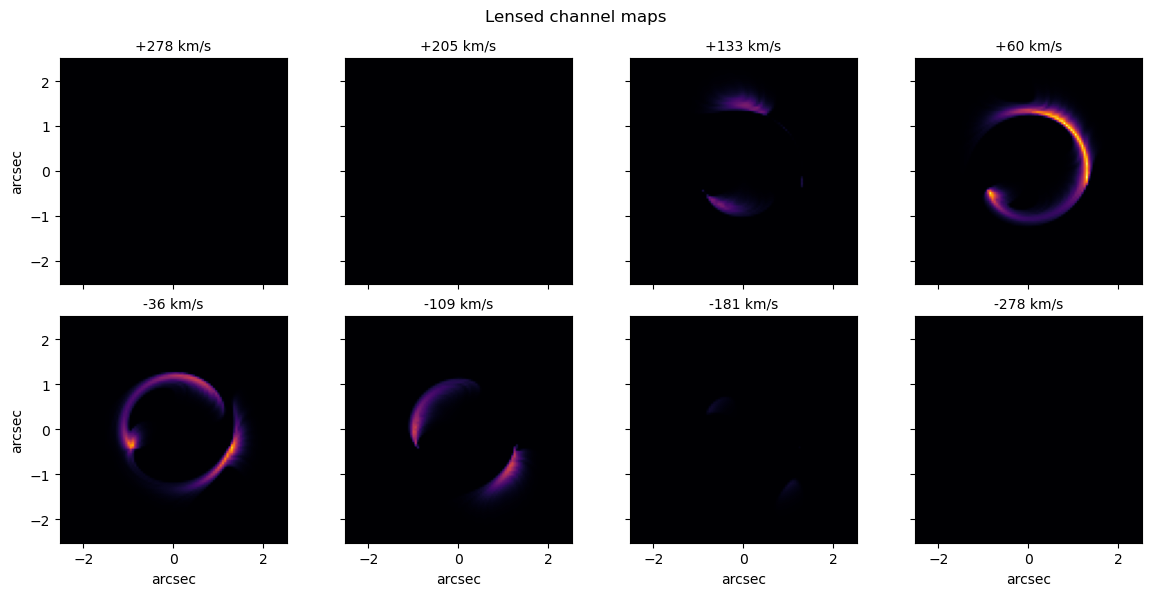

In [5]:
half_fov = pixscale * n_pix / 2
extent = (-half_fov, half_fov, -half_fov, half_fov)
cube_np = cube_lensed.detach().cpu().numpy()

chans = np.linspace(3, n_chan - 4, 8).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)
vmax = cube_np.max()
for ax, ch in zip(axes.ravel(), chans):
    ax.imshow(cube_np[ch], origin="lower", cmap="inferno",
              extent=extent, vmin=0, vmax=vmax)
    ax.set_title(f"{vel_np[ch]:+.0f} km/s", fontsize=10)
for ax in axes[-1]: ax.set_xlabel("arcsec")
for ax in axes[:, 0]: ax.set_ylabel("arcsec")
fig.suptitle("Lensed channel maps")
plt.tight_layout(); plt.show()

## 4. Lensed vs unlensed

Render the *same source* without the lens (fresh model instances — a
renderer takes ownership of its velocity model's inclination) on a finer
grid centred on the source, and compare moment maps.

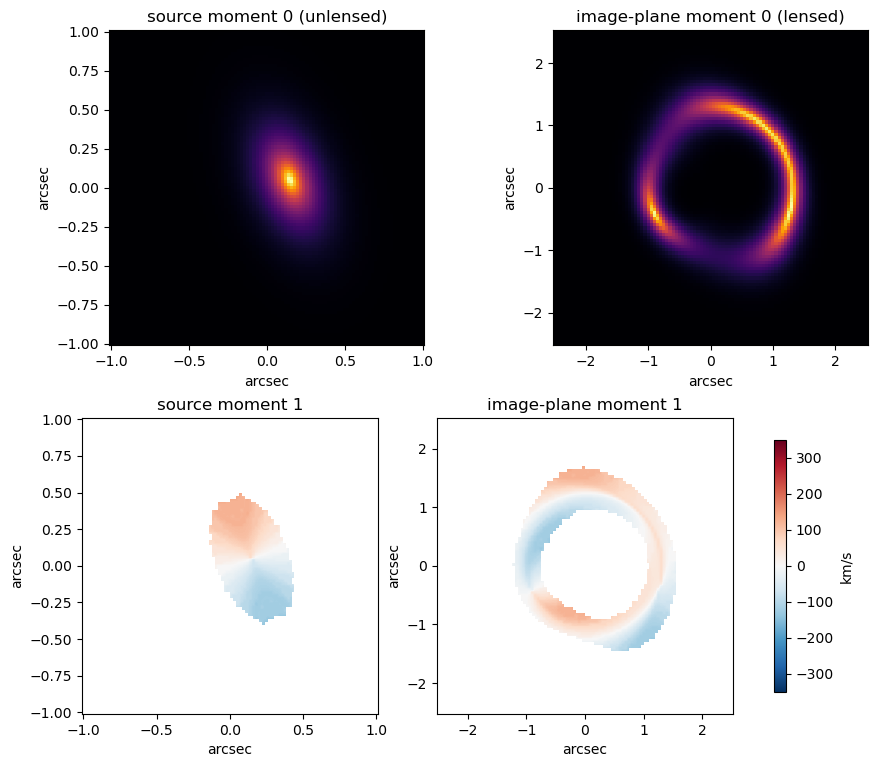

In [6]:
intensity2 = ExponentialDisk2D()
velocity2 = SersicMGE(N_MGE_components=20, distance_Mpc=D_A_Mpc, soft=1.0,
                      r_max_pc=3e4, device=device, dtype=dtype)
src_sim = AnalyticInverse(intensity2, velocity2, freqs,
                          pixel_scale_arcsec=0.02, N_pix_x=n_pix,
                          K_vel=8, oversamp_xy=4, oversamp_v=4,
                          device=device, dtype=dtype, line=line_hz)
theta_src = torch.tensor([pars[p.name] for p in src_sim.dynamic_params],
                         device=device, dtype=dtype)
cube_src = src_sim.forward(theta_src).detach().cpu().numpy()
extent_src = (-0.02 * n_pix / 2, 0.02 * n_pix / 2,
              -0.02 * n_pix / 2, 0.02 * n_pix / 2)

def clipped_mom1(cube_chw, frac=0.1):
    c = np.moveaxis(cube_chw, 0, -1)
    c = np.where(c > frac * c.max(), c, 0.0)
    with np.errstate(invalid="ignore"):        # empty pixels divide 0/0 -> NaN
        m1 = velocity_map(c, vel_np)
    return np.where(c.sum(axis=2) > 0, m1, np.nan)

mom0_src, mom1_src = cube_src.sum(0), clipped_mom1(cube_src)
mom0_img, mom1_img = cube_np.sum(0), clipped_mom1(cube_np)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9))
axes[0, 0].imshow(mom0_src, origin="lower", cmap="inferno", extent=extent_src)
axes[0, 0].set_title("source moment 0 (unlensed)")
axes[0, 1].imshow(mom0_img, origin="lower", cmap="inferno", extent=extent)
axes[0, 1].set_title("image-plane moment 0 (lensed)")
vext = np.abs(vel_np).max()
vnorm = colors.TwoSlopeNorm(vcenter=0, vmin=-vext, vmax=vext)
im10 = axes[1, 0].imshow(mom1_src, origin="lower", cmap="RdBu_r",
                         extent=extent_src, norm=vnorm)
axes[1, 0].set_title("source moment 1")
im11 = axes[1, 1].imshow(mom1_img, origin="lower", cmap="RdBu_r",
                         extent=extent, norm=vnorm)
axes[1, 1].set_title("image-plane moment 1")
fig.colorbar(im11, ax=axes[1, :], shrink=0.8, label="km/s")
for ax in axes.ravel():
    ax.set_xlabel("arcsec"); ax.set_ylabel("arcsec")
plt.show()

The velocity gradient of the source survives lensing (surface brightness —
and line-of-sight velocity — are conserved along rays), so the red and
blue sides of the disk map into distinct arcs. Fitting these data
constrains the lens model *and* the source rotation curve simultaneously.

## 5. Fitting lensed kinematics

Everything from the [fitting tutorial](05_fitting_mock_data.ipynb) carries
over unchanged: wrap `AnalyticLens` in `VisibilityCubePadded`, and the
lens parameters (left static above) can be made dynamic simply by not
fixing them — they then appear in `dynamic_params` and are fit alongside
the source.

Practical notes:

- **Lens-centre guard.** Image-plane pixels that raytrace to (numerically)
  infinite source radius are zeroed rather than propagating NaNs — a
  single bad pixel would otherwise poison the flux normalization of the
  whole cube and reject valid posterior samples.
- **Memory.** For large grids, `chunk_v` processes the render in spatial
  tiles at some speed cost.
- **`line` is required** for `AnalyticLens` (in the same units as
  `freq_axis` — Hz here), unlike the unlensed renderers where it defaults
  to CO(2–1) in GHz.